# Overlap Relative Structure Preservation

This notebook evaluates whether relational structure is preserved across datasets.

For each dataset pair and each matched `cell_type + time` context with at least `10` shared compounds:

- keep the matched dose-specific `drug + line + time` conditions as separate matched conditions
- load the grouped-replicate DE signatures from the source line-level `.h5ad` files
- restrict both datasets to the same shared gene set between the two datasets for that line pair
- define `direct(c)` for each matched condition `c` as the cross-dataset Spearman across genes
- define `relation(c)` for each matched condition `c` as the Spearman agreement between its within-dataset relational profile to all other matched conditions in that same `line + time` context

Here `c` is a matched `compound + left dose + right dose + line + time` condition pair, so different matched doses are kept separate rather than averaged first.

The notebook evaluates these condition-level scores on two gene spaces:

- the usual pairwise shared gene set for the dataset pair / line comparison
- the line-specific multi-dataset gene set for that `cell_type`, defined as the genes shared across all active datasets that retain that line, exposed via `*_global` columns in the saved tables

This makes the comparison fair: within each evaluation track, both `direct(c)` and `relation(c)` are computed on the same shared gene space.

The notebook then compares `direct(c)` and `relation(c)` directly at the matched-condition level, with context summaries and pair summaries using the same context weighting.

Outputs are written to `results/overlap_relative_structure_preservation/`.


In [19]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
import itertools

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import rankdata


In [20]:
DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "sciplex",
    "tahoe",
]
DISPLAY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "sciplex": "sci-Plex",
    "tahoe": "Tahoe-100M",
}
SOURCE_DATASET_DIRS = {
    "sciplex": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/sciplex/deg_data/group_rep/full/qc_false/filter_min_cells_10/results"),
    "tahoe": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/tahoe/deg_data/group_rep/full/qc_false/filter_min_cells_50/results"),
    "l1000_phase1": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/l1000_phase1/deg_data/group_rep/full/qc_false/filter_min_cells_0/results"),
    "l1000_phase2": Path("/lustre/groups/ml01/workspace/olga.novitskaia/data_updated/l1000_phase2/deg_data/group_rep/full/qc_false/filter_min_cells_0/results"),
}
MAX_LOG10_DOSE_DIFF = 1.0
MIN_CONTEXT_SHARED_DRUGS = 10
MIN_SHARED_COMPOUNDS_FOR_STRUCTURE = MIN_CONTEXT_SHARED_DRUGS
TOP_K = 50
NUMERIC_SIG_FIGS = 12


def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
DIRECT_SCORE_DIR = REPO_ROOT / "results" / "overlap_signature_similarity_group_rep"
OUTPUT_DIR = REPO_ROOT / "results" / "overlap_relative_structure_preservation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Direct-score directory: {DIRECT_SCORE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Repository root: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis
Overlap directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads
Direct-score directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_signature_similarity_group_rep
Output directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_relative_structure_preservation


In [21]:
def pretty_label(dataset_name: str) -> str:
    return DISPLAY_LABELS.get(dataset_name, dataset_name)


def format_numeric(value: float) -> str:
    formatted = f"{value:.{NUMERIC_SIG_FIGS}g}"
    return "0" if formatted == "-0" else formatted


def coerce_control_mask(values: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(values):
        return values.fillna(False).astype(bool)
    normalized = values.astype("string").fillna("").astype(str).str.strip().str.lower()
    return normalized.isin({"true", "1", "yes"})


def safe_pearson(left_values: np.ndarray, right_values: np.ndarray) -> float:
    left_values = np.asarray(left_values, dtype=np.float64)
    right_values = np.asarray(right_values, dtype=np.float64)
    mask = np.isfinite(left_values) & np.isfinite(right_values)
    left_values = left_values[mask]
    right_values = right_values[mask]
    if left_values.size < 2:
        return float("nan")
    if np.allclose(left_values, left_values[0]) or np.allclose(right_values, right_values[0]):
        return float("nan")
    return float(np.corrcoef(left_values, right_values)[0, 1])


def safe_spearman(left_values: np.ndarray, right_values: np.ndarray) -> float:
    left_values = np.asarray(left_values, dtype=np.float64)
    right_values = np.asarray(right_values, dtype=np.float64)
    mask = np.isfinite(left_values) & np.isfinite(right_values)
    left_values = left_values[mask]
    right_values = right_values[mask]
    if left_values.size < 2:
        return float("nan")
    left_ranks = rankdata(left_values, method="average")
    right_ranks = rankdata(right_values, method="average")
    if np.allclose(left_ranks, left_ranks[0]) or np.allclose(right_ranks, right_ranks[0]):
        return float("nan")
    return float(np.corrcoef(left_ranks, right_ranks)[0, 1])


EMPTY_CONDITION_FRAME = pd.DataFrame(
    columns=[
        "dataset_name",
        "pubchem_cid",
        "cell_type",
        "pert_time_h",
        "pert_dose_uM",
        "time_key",
        "dose_key",
        "log10_dose",
    ]
)


def load_overlap_conditions(dataset_name: str, overlap_dir: Path = OVERLAP_DIR) -> pd.DataFrame:
    h5ad_path = overlap_dir / f"{dataset_name}_overlap_filtered.h5ad"
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing overlap file: {h5ad_path}")

    adata = ad.read_h5ad(h5ad_path, backed="r")
    try:
        obs = adata.obs.copy()
    finally:
        adata.file.close()

    if obs.empty:
        return EMPTY_CONDITION_FRAME.copy()
    obs = obs.loc[~coerce_control_mask(obs["is_control"])].copy()
    if obs.empty:
        return EMPTY_CONDITION_FRAME.copy()

    frame = pd.DataFrame(index=obs.index.copy())
    frame["dataset_name"] = dataset_name
    frame["pubchem_cid"] = obs["pubchem_cid"].astype("string").fillna("").astype(str).str.strip()
    frame["cell_type"] = obs["cell_type"].astype("string").fillna("").astype(str).str.strip()
    frame["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    if frame.empty:
        return EMPTY_CONDITION_FRAME.copy()

    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    frame = frame.drop_duplicates(
        subset=["pubchem_cid", "cell_type", "time_key", "dose_key"]
    ).reset_index(drop=True)
    return frame[EMPTY_CONDITION_FRAME.columns.tolist()]


def build_condition_groups(frame: pd.DataFrame) -> dict[tuple[str, str, str], np.ndarray]:
    if frame.empty:
        return {}
    grouped = frame.groupby(["pubchem_cid", "cell_type", "time_key"], sort=False).groups
    return {
        key: np.asarray(list(row_positions), dtype=np.int64)
        for key, row_positions in grouped.items()
    }


def build_dataset_index(dataset_name: str) -> dict[str, object]:
    frame = load_overlap_conditions(dataset_name)
    return {
        "frame": frame,
        "groups": build_condition_groups(frame),
    }


def active_dataset_names(dataset_indices: dict[str, dict[str, object]]) -> list[str]:
    return [
        dataset_name
        for dataset_name in DATASET_ORDER
        if dataset_name in dataset_indices and not dataset_indices[dataset_name]["frame"].empty
    ]


def mutual_nearest_logdose_pairs(
    left_log10_doses: np.ndarray,
    right_log10_doses: np.ndarray,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> np.ndarray:
    if left_log10_doses.size == 0 or right_log10_doses.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    diff = np.abs(left_log10_doses[:, None] - right_log10_doses[None, :])
    left_min = diff.min(axis=1, keepdims=True)
    right_min = diff.min(axis=0, keepdims=True)
    is_mnn = (
        (diff <= max_log10_dose_diff + 1e-12)
        & np.isclose(diff, left_min, rtol=0.0, atol=1e-12)
        & np.isclose(diff, right_min, rtol=0.0, atol=1e-12)
    )
    return np.argwhere(is_mnn)


MATCHED_CONDITION_COLUMNS = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_dose_key",
    "right_dose_key",
    "left_log10_dose",
    "right_log10_dose",
    "abs_delta_log10_dose",
    "n_context_matching_drugs",
]


def pair_condition_match_frame(
    left_dataset: str,
    right_dataset: str,
    left_index: dict[str, object],
    right_index: dict[str, object],
    *,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
    min_context_shared_drugs: int = MIN_CONTEXT_SHARED_DRUGS,
) -> pd.DataFrame:
    left_frame = left_index["frame"]
    right_frame = right_index["frame"]
    left_groups = left_index["groups"]
    right_groups = right_index["groups"]

    if left_frame.empty or right_frame.empty:
        return pd.DataFrame(columns=MATCHED_CONDITION_COLUMNS)

    shared_keys = sorted(set(left_groups) & set(right_groups))
    if not shared_keys:
        return pd.DataFrame(columns=MATCHED_CONDITION_COLUMNS)

    left_log10_dose = left_frame["log10_dose"].to_numpy(dtype=np.float64)
    right_log10_dose = right_frame["log10_dose"].to_numpy(dtype=np.float64)
    left_dose_keys = left_frame["dose_key"].to_numpy(dtype=object)
    right_dose_keys = right_frame["dose_key"].to_numpy(dtype=object)

    context_matching_drugs: dict[tuple[str, str], set[str]] = defaultdict(set)
    rows: list[dict[str, object]] = []

    for pubchem_cid, cell_type, time_key in shared_keys:
        left_rows = left_groups[(pubchem_cid, cell_type, time_key)]
        right_rows = right_groups[(pubchem_cid, cell_type, time_key)]
        pairs = mutual_nearest_logdose_pairs(
            left_log10_doses=left_log10_dose[left_rows],
            right_log10_doses=right_log10_dose[right_rows],
            max_log10_dose_diff=max_log10_dose_diff,
        )
        if pairs.size == 0:
            continue

        for left_pos, right_pos in pairs:
            left_row = int(left_rows[left_pos])
            right_row = int(right_rows[right_pos])
            left_dose_key = str(left_dose_keys[left_row])
            right_dose_key = str(right_dose_keys[right_row])
            context_matching_drugs[(str(cell_type), str(time_key))].add(str(pubchem_cid))
            rows.append(
                {
                    "dataset_a": left_dataset,
                    "dataset_b": right_dataset,
                    "cell_type": str(cell_type),
                    "time_key": str(time_key),
                    "pubchem_cid": str(pubchem_cid),
                    "left_dose_key": left_dose_key,
                    "right_dose_key": right_dose_key,
                    "left_log10_dose": float(left_log10_dose[left_row]),
                    "right_log10_dose": float(right_log10_dose[right_row]),
                    "abs_delta_log10_dose": float(abs(left_log10_dose[left_row] - right_log10_dose[right_row])),
                }
            )

    if not rows:
        return pd.DataFrame(columns=MATCHED_CONDITION_COLUMNS)

    frame = pd.DataFrame(rows)
    qualifying_context_drug_counts = {
        context_key: len(compounds)
        for context_key, compounds in context_matching_drugs.items()
        if len(compounds) >= int(min_context_shared_drugs)
    }
    if not qualifying_context_drug_counts:
        return pd.DataFrame(columns=MATCHED_CONDITION_COLUMNS)

    frame["_context_key"] = list(zip(frame["cell_type"], frame["time_key"]))
    frame["n_context_matching_drugs"] = frame["_context_key"].map(qualifying_context_drug_counts)
    frame = frame.loc[frame["n_context_matching_drugs"].notna()].copy()
    frame["n_context_matching_drugs"] = frame["n_context_matching_drugs"].astype(int)
    frame = frame.drop(columns="_context_key")
    return frame[MATCHED_CONDITION_COLUMNS].reset_index(drop=True)


In [22]:
@dataclass
class LineSource:
    dataset_name: str
    cell_type: str
    path: Path
    adata: ad.AnnData = field(init=False, repr=False)
    obs: pd.DataFrame = field(init=False, repr=False)
    condition_rows: dict[tuple[str, str, str], np.ndarray] = field(init=False, repr=False)
    unique_gene_keys: np.ndarray = field(init=False, repr=False)
    unique_gene_positions: np.ndarray = field(init=False, repr=False)
    gene_to_pos: dict[str, int] = field(init=False, repr=False)
    _condition_vector_cache: dict[tuple[str, str, str, str], np.ndarray] = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self) -> None:
        self.adata = ad.read_h5ad(self.path, backed="r")
        obs = self.adata.obs.copy()
        row_positions = np.arange(self.adata.n_obs, dtype=np.int64)

        if "is_control" not in obs.columns:
            raise KeyError(f"{self.path} is missing obs['is_control']")

        control_mask = coerce_control_mask(obs["is_control"]).to_numpy(dtype=bool)
        obs = obs.loc[~control_mask].copy()
        row_positions = row_positions[~control_mask]
        obs["source_row_pos"] = row_positions

        for column_name in ["cell_type", "pubchem_cid"]:
            obs[column_name] = obs[column_name].astype("string").fillna("").astype(str).str.strip()
        obs["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
        obs["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")
        obs["time_key"] = obs["pert_time_h"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) else ""
        )
        obs["dose_key"] = obs["pert_dose_uM"].map(
            lambda value: format_numeric(float(value)) if pd.notna(value) and float(value) > 0 else ""
        )

        valid_mask = (
            (obs["cell_type"] == self.cell_type)
            & (obs["pubchem_cid"] != "")
            & np.isfinite(obs["pert_time_h"].to_numpy(dtype=float))
            & np.isfinite(obs["pert_dose_uM"].to_numpy(dtype=float))
            & (obs["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
        )
        obs = obs.loc[valid_mask].copy()
        self.obs = obs

        grouped = obs.groupby(["pubchem_cid", "time_key", "dose_key"], sort=False)["source_row_pos"].apply(list)
        self.condition_rows = {
            (str(pubchem_cid), str(time_key), str(dose_key)): np.asarray(row_positions, dtype=np.int64)
            for (pubchem_cid, time_key, dose_key), row_positions in grouped.items()
        }

        var = self.adata.var.copy()
        if "symbol" in var.columns:
            gene_key_series = pd.Series(
                var["symbol"].astype("string").fillna("").astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        else:
            gene_key_series = pd.Series(
                pd.Index(self.adata.var_names.astype(str)).astype(str).str.strip().to_numpy(),
                index=np.arange(self.adata.n_vars, dtype=np.int64),
            )
        keep_mask = (gene_key_series != "") & ~gene_key_series.duplicated(keep="first")
        self.unique_gene_positions = gene_key_series.index[keep_mask].to_numpy(dtype=np.int64)
        self.unique_gene_keys = gene_key_series.loc[keep_mask].to_numpy(dtype=object)
        self.gene_to_pos = {
            str(gene_key): int(pos)
            for pos, gene_key in enumerate(self.unique_gene_keys.tolist())
        }

    def has_condition(self, pubchem_cid: str, time_key: str, dose_key: str) -> bool:
        return (str(pubchem_cid), str(time_key), str(dose_key)) in self.condition_rows

    def condition_n_rows(self, pubchem_cid: str, time_key: str, dose_key: str) -> int:
        return int(len(self.condition_rows[(str(pubchem_cid), str(time_key), str(dose_key))]))

    def get_condition_vector(self, pubchem_cid: str, time_key: str, dose_key: str, layer_name: str) -> np.ndarray:
        cache_key = (layer_name, str(pubchem_cid), str(time_key), str(dose_key))
        if cache_key not in self._condition_vector_cache:
            row_positions = self.condition_rows[(str(pubchem_cid), str(time_key), str(dose_key))]
            matrix = np.asarray(self.adata.layers[layer_name][row_positions], dtype=np.float32)
            if matrix.ndim == 1:
                matrix = matrix[np.newaxis, :]
            vector = matrix[:, self.unique_gene_positions].mean(axis=0, dtype=np.float64)
            self._condition_vector_cache[cache_key] = np.asarray(vector, dtype=np.float32)
        return self._condition_vector_cache[cache_key]

    def close(self) -> None:
        self.adata.file.close()


def resolve_line_path(dataset_name: str, cell_type: str) -> Path:
    dataset_dir = SOURCE_DATASET_DIRS[dataset_name]
    candidates = [
        dataset_dir / f"{cell_type}_de.h5ad",
        dataset_dir / f"{cell_type}.h5ad",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find a line file for dataset={dataset_name}, cell_type={cell_type} in {dataset_dir}"
    )


LINE_SOURCE_CACHE: dict[tuple[str, str], LineSource] = {}
COMMON_GENE_CACHE: dict[tuple[str, str, str], tuple[np.ndarray, np.ndarray, np.ndarray]] = {}


def get_line_source(dataset_name: str, cell_type: str) -> LineSource:
    cache_key = (dataset_name, cell_type)
    if cache_key not in LINE_SOURCE_CACHE:
        LINE_SOURCE_CACHE[cache_key] = LineSource(
            dataset_name=dataset_name,
            cell_type=cell_type,
            path=resolve_line_path(dataset_name, cell_type),
        )
    return LINE_SOURCE_CACHE[cache_key]


def shared_gene_positions(left_source: LineSource, right_source: LineSource) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    cache_key = (left_source.dataset_name, right_source.dataset_name, left_source.cell_type)
    if cache_key not in COMMON_GENE_CACHE:
        shared_genes = [
            gene_key
            for gene_key in left_source.unique_gene_keys.tolist()
            if str(gene_key) in right_source.gene_to_pos
        ]
        left_positions = np.fromiter(
            (left_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        right_positions = np.fromiter(
            (right_source.gene_to_pos[str(gene_key)] for gene_key in shared_genes),
            dtype=np.int64,
            count=len(shared_genes),
        )
        COMMON_GENE_CACHE[cache_key] = (
            np.asarray(shared_genes, dtype=object),
            left_positions,
            right_positions,
        )
    return COMMON_GENE_CACHE[cache_key]

LINE_GLOBAL_SHARED_GENE_KEYS: dict[str, np.ndarray] = {}
GLOBAL_GENE_POSITION_CACHE: dict[tuple[str, str], np.ndarray] = {}


def set_global_shared_gene_keys(
    retained_lines: dict[str, list[str]],
    dataset_names: list[str],
) -> dict[str, np.ndarray]:
    global LINE_GLOBAL_SHARED_GENE_KEYS, GLOBAL_GENE_POSITION_CACHE

    cell_types = sorted(
        {
            cell_type
            for dataset_name in dataset_names
            for cell_type in retained_lines.get(dataset_name, [])
        }
    )
    line_gene_map: dict[str, np.ndarray] = {}
    for cell_type in cell_types:
        gene_sets: list[set[str]] = []
        for dataset_name in dataset_names:
            if cell_type not in retained_lines.get(dataset_name, []):
                continue
            source = get_line_source(dataset_name, cell_type)
            gene_sets.append({str(gene_key) for gene_key in source.unique_gene_keys.tolist()})
        if not gene_sets:
            line_gene_map[cell_type] = np.empty(0, dtype=object)
        else:
            line_gene_map[cell_type] = np.asarray(sorted(set.intersection(*gene_sets)), dtype=object)

    LINE_GLOBAL_SHARED_GENE_KEYS = line_gene_map
    GLOBAL_GENE_POSITION_CACHE = {}
    return LINE_GLOBAL_SHARED_GENE_KEYS


def global_gene_positions(source: LineSource) -> tuple[np.ndarray, np.ndarray]:
    cache_key = (source.dataset_name, source.cell_type)
    line_gene_keys = LINE_GLOBAL_SHARED_GENE_KEYS.get(source.cell_type, np.empty(0, dtype=object))
    if line_gene_keys.size == 0:
        return line_gene_keys, np.empty(0, dtype=np.int64)
    if cache_key not in GLOBAL_GENE_POSITION_CACHE:
        missing_gene_keys = [
            str(gene_key)
            for gene_key in line_gene_keys.tolist()
            if str(gene_key) not in source.gene_to_pos
        ]
        if missing_gene_keys:
            raise KeyError(
                f"Line-specific shared-gene set is inconsistent for {(source.dataset_name, source.cell_type)}; "
                f"missing {len(missing_gene_keys)} genes."
            )
        GLOBAL_GENE_POSITION_CACHE[cache_key] = np.fromiter(
            (source.gene_to_pos[str(gene_key)] for gene_key in line_gene_keys.tolist()),
            dtype=np.int64,
            count=int(line_gene_keys.size),
        )
    return line_gene_keys, GLOBAL_GENE_POSITION_CACHE[cache_key]



def pairwise_signature_similarity_vector(signature_matrix: np.ndarray) -> np.ndarray:
    signature_matrix = np.asarray(signature_matrix, dtype=np.float64)
    if signature_matrix.ndim != 2 or signature_matrix.shape[0] < 2:
        return np.empty(0, dtype=np.float64)
    ranked = np.vstack([rankdata(row, method="average") for row in signature_matrix])
    sims = np.corrcoef(ranked)
    tri_upper = np.triu_indices(signature_matrix.shape[0], k=1)
    return np.asarray(sims[tri_upper], dtype=np.float64)


def row_spearman_similarity_matrix(signature_matrix: np.ndarray) -> np.ndarray:
    signature_matrix = np.asarray(signature_matrix, dtype=np.float64)
    if signature_matrix.ndim != 2 or signature_matrix.shape[0] == 0:
        return np.empty((0, 0), dtype=np.float64)
    if signature_matrix.shape[0] == 1:
        return np.full((1, 1), np.nan, dtype=np.float64)
    ranked = np.vstack([rankdata(row, method="average") for row in signature_matrix])
    return np.asarray(np.corrcoef(ranked), dtype=np.float64)


def direct_context_summary_frame(direct_score_dir: Path = DIRECT_SCORE_DIR) -> pd.DataFrame:
    drug_line_time_metrics_path = direct_score_dir / "matched_drug_line_time_metric_summary.tsv"
    if drug_line_time_metrics_path.exists():
        frame = pd.read_csv(drug_line_time_metrics_path, sep="	")
    else:
        matched_pair_metrics_path = direct_score_dir / "matched_sample_pair_metrics.tsv"
        if not matched_pair_metrics_path.exists():
            raise FileNotFoundError(
                f"Missing direct cross-dataset metric file: {matched_pair_metrics_path}. Run overlap_group_rep_signature_similarity.ipynb first."
            )
        frame = pd.read_csv(matched_pair_metrics_path, sep="	")
        drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]
        for column_name in drug_line_time_group_columns:
            frame[column_name] = frame[column_name].astype("string").fillna("").astype(str)
        agg = {
            "n_direct_sample_pairs": ("left_obs_id", "size"),
            "mean_direct_observed_spearman_logfc": ("observed_spearman_logfc", "mean"),
            "mean_direct_observed_spearman_t": ("observed_spearman_t", "mean"),
            f"mean_direct_observed_signed_overlap_t_top{TOP_K}": (f"observed_signed_overlap_t_top{TOP_K}", "mean"),
        }
        if "observed_spearman_logfc_global" in frame.columns:
            agg["mean_direct_observed_spearman_logfc_global"] = ("observed_spearman_logfc_global", "mean")
            agg["mean_direct_observed_spearman_t_global"] = ("observed_spearman_t_global", "mean")
            agg[f"mean_direct_observed_signed_overlap_t_top{TOP_K}_global"] = (
                f"observed_signed_overlap_t_top{TOP_K}_global",
                "mean",
            )
        frame = frame.groupby(drug_line_time_group_columns, as_index=False).agg(**agg)
    drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]
    for column_name in drug_line_time_group_columns:
        frame[column_name] = frame[column_name].astype("string").fillna("").astype(str)
    context_join_columns = ["dataset_a", "dataset_b", "cell_type", "time_key"]
    agg = {
        "n_direct_drug_line_time_cases": ("pubchem_cid", "size"),
        "n_direct_drugs": ("pubchem_cid", "nunique"),
        "mean_direct_observed_spearman_logfc": (
            "mean_observed_spearman_logfc" if "mean_observed_spearman_logfc" in frame.columns else "mean_direct_observed_spearman_logfc",
            "mean",
        ),
        "mean_direct_observed_spearman_t": (
            "mean_observed_spearman_t" if "mean_observed_spearman_t" in frame.columns else "mean_direct_observed_spearman_t",
            "mean",
        ),
        f"mean_direct_observed_signed_overlap_t_top{TOP_K}": (
            f"mean_observed_signed_overlap_t_top{TOP_K}" if f"mean_observed_signed_overlap_t_top{TOP_K}" in frame.columns else f"mean_direct_observed_signed_overlap_t_top{TOP_K}",
            "mean",
        ),
    }
    if "mean_observed_spearman_logfc_global" in frame.columns or "mean_direct_observed_spearman_logfc_global" in frame.columns:
        agg["mean_direct_observed_spearman_logfc_global"] = (
            "mean_observed_spearman_logfc_global" if "mean_observed_spearman_logfc_global" in frame.columns else "mean_direct_observed_spearman_logfc_global",
            "mean",
        )
        agg["mean_direct_observed_spearman_t_global"] = (
            "mean_observed_spearman_t_global" if "mean_observed_spearman_t_global" in frame.columns else "mean_direct_observed_spearman_t_global",
            "mean",
        )
        agg[f"mean_direct_observed_signed_overlap_t_top{TOP_K}_global"] = (
            f"mean_observed_signed_overlap_t_top{TOP_K}_global" if f"mean_observed_signed_overlap_t_top{TOP_K}_global" in frame.columns else f"mean_direct_observed_signed_overlap_t_top{TOP_K}_global",
            "mean",
        )
    return (
        frame.groupby(context_join_columns, as_index=False)
        .agg(**agg)
        .sort_values(context_join_columns)
        .reset_index(drop=True)
    )

def close_all_line_sources() -> None:
    for line_source in LINE_SOURCE_CACHE.values():
        line_source.close()


In [23]:
dataset_indices = {dataset_name: build_dataset_index(dataset_name) for dataset_name in DATASET_ORDER}
active_datasets = active_dataset_names(dataset_indices)
if not active_datasets:
    raise ValueError("No overlap-filtered non-control conditions were found for the configured datasets.")

print("Datasets in scope:", ", ".join(pretty_label(dataset_name) for dataset_name in active_datasets))

retained_lines = {
    dataset_name: sorted(dataset_indices[dataset_name]["frame"]["cell_type"].unique().tolist())
    for dataset_name in active_datasets
}
line_global_gene_keys = set_global_shared_gene_keys(retained_lines, active_datasets)
line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
print(f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} retained lines.")
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no retained line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        f"Line-specific shared-gene count range across retained lines: {min(line_global_gene_counts.values()):,} to {max(line_global_gene_counts.values()):,}"
    )

matched_condition_frames: list[pd.DataFrame] = []
for dataset_a, dataset_b in itertools.combinations(active_datasets, 2):
    frame = pair_condition_match_frame(
        left_dataset=dataset_a,
        right_dataset=dataset_b,
        left_index=dataset_indices[dataset_a],
        right_index=dataset_indices[dataset_b],
    )
    if not frame.empty:
        matched_condition_frames.append(frame)

if not matched_condition_frames:
    raise ValueError("No matched condition-level rows were found.")

matched_conditions = pd.concat(matched_condition_frames, ignore_index=True)
matched_conditions_path = OUTPUT_DIR / "matched_condition_level_pairs.tsv"
matched_conditions.to_csv(matched_conditions_path, sep="\t", index=False)
print(f"Saved matched condition-level rows to {matched_conditions_path}")

context_summary = (
    matched_conditions.groupby(
        ["dataset_a", "dataset_b", "cell_type", "time_key"],
        as_index=False,
    )
    .agg(
        n_shared_compounds=("pubchem_cid", "nunique"),
        mean_abs_delta_log10_dose=("abs_delta_log10_dose", "mean"),
        n_context_matching_drugs=("n_context_matching_drugs", "first"),
        n_matched_conditions=("pubchem_cid", "size"),
    )
    .sort_values(["dataset_a", "dataset_b", "cell_type", "time_key"])
    .reset_index(drop=True)
)

context_summary_display = context_summary.copy()
context_summary_display["dataset_a"] = context_summary_display["dataset_a"].map(pretty_label)
context_summary_display["dataset_b"] = context_summary_display["dataset_b"].map(pretty_label)
display(context_summary_display)

print(
    f"Keeping only line/time contexts with at least {MIN_SHARED_COMPOUNDS_FOR_STRUCTURE} shared compounds, while keeping matched dose-specific conditions separate within each retained context."
)

structure_contexts = context_summary.loc[
    context_summary["n_shared_compounds"] >= MIN_SHARED_COMPOUNDS_FOR_STRUCTURE
].copy().reset_index(drop=True)
print(f"Structure contexts retained: {len(structure_contexts):,}")


Datasets in scope: L1000 Phase I, L1000 Phase II, sci-Plex, Tahoe-100M


/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.o

Line-specific shared-gene sets computed for 4 retained lines.
Line-specific shared-gene count range across retained lines: 599 to 941
Saved matched condition-level rows to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_relative_structure_preservation/matched_condition_level_pairs.tsv


,dataset_a,dataset_b,cell_type,time_key,n_shared_compounds,mean_abs_delta_log10_dose,n_context_matching_drugs,n_matched_conditions
0,L1000 Phase I,L1000 Phase II,CVCL_0023,24,139,0.017144,139,213
1,L1000 Phase I,L1000 Phase II,CVCL_0023,6,24,0.190801,24,24
2,L1000 Phase I,L1000 Phase II,CVCL_0031,24,57,0.062465,57,124
3,L1000 Phase I,L1000 Phase II,CVCL_0320,24,12,0.375642,12,14
4,L1000 Phase I,sci-Plex,CVCL_0023,24,75,0.033881,75,113
5,L1000 Phase I,sci-Plex,CVCL_0031,24,90,0.059320,90,178
6,L1000 Phase I,Tahoe-100M,CVCL_0023,24,83,0.273623,83,95
7,L1000 Phase I,Tahoe-100M,CVCL_0320,24,20,0.297167,20,24
8,L1000 Phase I,Tahoe-100M,CVCL_0332,24,11,0.200687,11,33
9,L1000 Phase II,sci-Plex,CVCL_0023,24,44,0.041501,44,132


Keeping only line/time contexts with at least 10 shared compounds, while keeping matched dose-specific conditions separate within each retained context.
Structure contexts retained: 14


In [24]:
condition_records: list[dict[str, object]] = []
skipped_context_records: list[dict[str, object]] = []
missing_condition_records: list[dict[str, object]] = []

for _, context_row in structure_contexts.iterrows():
    dataset_a = str(context_row["dataset_a"])
    dataset_b = str(context_row["dataset_b"])
    cell_type = str(context_row["cell_type"])
    time_key = str(context_row["time_key"])

    group = matched_conditions.loc[
        (matched_conditions["dataset_a"] == dataset_a)
        & (matched_conditions["dataset_b"] == dataset_b)
        & (matched_conditions["cell_type"] == cell_type)
        & (matched_conditions["time_key"] == time_key)
    ].copy()
    group = group.drop_duplicates(subset=["pubchem_cid", "left_dose_key", "right_dose_key"]).reset_index(drop=True)

    print(
        f"Scoring relation {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / time={time_key}: "
        f"{group['pubchem_cid'].nunique()} shared compounds across {len(group)} matched conditions"
    )

    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    global_shared_genes, left_global_gene_pos = global_gene_positions(left_source)
    _, right_global_gene_pos = global_gene_positions(right_source)
    if shared_genes.size < 2 and global_shared_genes.size < 2:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_pairwise_and_global_shared_genes",
                "n_shared_genes": int(shared_genes.size),
                "n_global_shared_genes": int(global_shared_genes.size),
            }
        )
        continue

    resolved_meta: list[dict[str, object]] = []
    left_logfc_vectors: list[np.ndarray] = []
    right_logfc_vectors: list[np.ndarray] = []
    left_t_vectors: list[np.ndarray] = []
    right_t_vectors: list[np.ndarray] = []
    left_logfc_global_vectors: list[np.ndarray] = []
    right_logfc_global_vectors: list[np.ndarray] = []
    left_t_global_vectors: list[np.ndarray] = []
    right_t_global_vectors: list[np.ndarray] = []

    for _, condition_row in group.iterrows():
        pubchem_cid = str(condition_row["pubchem_cid"])
        left_dose_key = str(condition_row["left_dose_key"])
        right_dose_key = str(condition_row["right_dose_key"])
        has_left = left_source.has_condition(pubchem_cid, time_key, left_dose_key)
        has_right = right_source.has_condition(pubchem_cid, time_key, right_dose_key)
        if not (has_left and has_right):
            missing_condition_records.append(
                {
                    **context_row.to_dict(),
                    "pubchem_cid": pubchem_cid,
                    "left_dose_key": left_dose_key,
                    "right_dose_key": right_dose_key,
                    "left_has_condition": bool(has_left),
                    "right_has_condition": bool(has_right),
                }
            )
            continue

        left_logfc_full = left_source.get_condition_vector(pubchem_cid, time_key, left_dose_key, "logFC")
        right_logfc_full = right_source.get_condition_vector(pubchem_cid, time_key, right_dose_key, "logFC")
        left_t_full = left_source.get_condition_vector(pubchem_cid, time_key, left_dose_key, "t")
        right_t_full = right_source.get_condition_vector(pubchem_cid, time_key, right_dose_key, "t")

        if shared_genes.size >= 2:
            left_logfc_vectors.append(left_logfc_full[left_gene_pos])
            right_logfc_vectors.append(right_logfc_full[right_gene_pos])
            left_t_vectors.append(left_t_full[left_gene_pos])
            right_t_vectors.append(right_t_full[right_gene_pos])
        if global_shared_genes.size >= 2:
            left_logfc_global_vectors.append(left_logfc_full[left_global_gene_pos])
            right_logfc_global_vectors.append(right_logfc_full[right_global_gene_pos])
            left_t_global_vectors.append(left_t_full[left_global_gene_pos])
            right_t_global_vectors.append(right_t_full[right_global_gene_pos])

        resolved_meta.append(
            {
                "dataset_a": dataset_a,
                "dataset_b": dataset_b,
                "cell_type": cell_type,
                "time_key": time_key,
                "pubchem_cid": pubchem_cid,
                "left_dose_key": left_dose_key,
                "right_dose_key": right_dose_key,
                "left_log10_dose": float(condition_row["left_log10_dose"]),
                "right_log10_dose": float(condition_row["right_log10_dose"]),
                "abs_delta_log10_dose": float(condition_row["abs_delta_log10_dose"]),
                "n_context_matching_drugs": int(condition_row["n_context_matching_drugs"]),
            }
        )

    if len(resolved_meta) < 3:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_resolved_conditions",
                "n_shared_genes": int(shared_genes.size),
                "n_global_shared_genes": int(global_shared_genes.size),
                "n_resolved_conditions": int(len(resolved_meta)),
            }
        )
        continue

    n_conditions = len(resolved_meta)
    direct_spearman_logfc = np.full(n_conditions, np.nan, dtype=np.float64)
    relation_spearman_logfc = np.full(n_conditions, np.nan, dtype=np.float64)
    direct_spearman_t = np.full(n_conditions, np.nan, dtype=np.float64)
    relation_spearman_t = np.full(n_conditions, np.nan, dtype=np.float64)
    direct_spearman_logfc_global = np.full(n_conditions, np.nan, dtype=np.float64)
    relation_spearman_logfc_global = np.full(n_conditions, np.nan, dtype=np.float64)
    direct_spearman_t_global = np.full(n_conditions, np.nan, dtype=np.float64)
    relation_spearman_t_global = np.full(n_conditions, np.nan, dtype=np.float64)
    n_shared_genes_used = 0
    n_global_shared_genes_used = 0

    if left_logfc_vectors:
        left_logfc_matrix = np.asarray(left_logfc_vectors, dtype=np.float64)
        right_logfc_matrix = np.asarray(right_logfc_vectors, dtype=np.float64)
        left_t_matrix = np.asarray(left_t_vectors, dtype=np.float64)
        right_t_matrix = np.asarray(right_t_vectors, dtype=np.float64)

        finite_gene_mask = (
            np.isfinite(left_logfc_matrix).all(axis=0)
            & np.isfinite(right_logfc_matrix).all(axis=0)
            & np.isfinite(left_t_matrix).all(axis=0)
            & np.isfinite(right_t_matrix).all(axis=0)
        )
        left_logfc_matrix = left_logfc_matrix[:, finite_gene_mask]
        right_logfc_matrix = right_logfc_matrix[:, finite_gene_mask]
        left_t_matrix = left_t_matrix[:, finite_gene_mask]
        right_t_matrix = right_t_matrix[:, finite_gene_mask]

        if left_logfc_matrix.shape[1] >= 2:
            n_shared_genes_used = int(left_logfc_matrix.shape[1])
            left_logfc_similarity = row_spearman_similarity_matrix(left_logfc_matrix)
            right_logfc_similarity = row_spearman_similarity_matrix(right_logfc_matrix)
            left_t_similarity = row_spearman_similarity_matrix(left_t_matrix)
            right_t_similarity = row_spearman_similarity_matrix(right_t_matrix)
            for idx in range(n_conditions):
                other_mask = np.arange(n_conditions) != idx
                direct_spearman_logfc[idx] = safe_spearman(left_logfc_matrix[idx], right_logfc_matrix[idx])
                relation_spearman_logfc[idx] = safe_spearman(
                    left_logfc_similarity[idx, other_mask],
                    right_logfc_similarity[idx, other_mask],
                )
                direct_spearman_t[idx] = safe_spearman(left_t_matrix[idx], right_t_matrix[idx])
                relation_spearman_t[idx] = safe_spearman(
                    left_t_similarity[idx, other_mask],
                    right_t_similarity[idx, other_mask],
                )

    if left_logfc_global_vectors:
        left_logfc_global_matrix = np.asarray(left_logfc_global_vectors, dtype=np.float64)
        right_logfc_global_matrix = np.asarray(right_logfc_global_vectors, dtype=np.float64)
        left_t_global_matrix = np.asarray(left_t_global_vectors, dtype=np.float64)
        right_t_global_matrix = np.asarray(right_t_global_vectors, dtype=np.float64)

        finite_global_gene_mask = (
            np.isfinite(left_logfc_global_matrix).all(axis=0)
            & np.isfinite(right_logfc_global_matrix).all(axis=0)
            & np.isfinite(left_t_global_matrix).all(axis=0)
            & np.isfinite(right_t_global_matrix).all(axis=0)
        )
        left_logfc_global_matrix = left_logfc_global_matrix[:, finite_global_gene_mask]
        right_logfc_global_matrix = right_logfc_global_matrix[:, finite_global_gene_mask]
        left_t_global_matrix = left_t_global_matrix[:, finite_global_gene_mask]
        right_t_global_matrix = right_t_global_matrix[:, finite_global_gene_mask]

        if left_logfc_global_matrix.shape[1] >= 2:
            n_global_shared_genes_used = int(left_logfc_global_matrix.shape[1])
            left_logfc_similarity_global = row_spearman_similarity_matrix(left_logfc_global_matrix)
            right_logfc_similarity_global = row_spearman_similarity_matrix(right_logfc_global_matrix)
            left_t_similarity_global = row_spearman_similarity_matrix(left_t_global_matrix)
            right_t_similarity_global = row_spearman_similarity_matrix(right_t_global_matrix)
            for idx in range(n_conditions):
                other_mask = np.arange(n_conditions) != idx
                direct_spearman_logfc_global[idx] = safe_spearman(
                    left_logfc_global_matrix[idx],
                    right_logfc_global_matrix[idx],
                )
                relation_spearman_logfc_global[idx] = safe_spearman(
                    left_logfc_similarity_global[idx, other_mask],
                    right_logfc_similarity_global[idx, other_mask],
                )
                direct_spearman_t_global[idx] = safe_spearman(
                    left_t_global_matrix[idx],
                    right_t_global_matrix[idx],
                )
                relation_spearman_t_global[idx] = safe_spearman(
                    left_t_similarity_global[idx, other_mask],
                    right_t_similarity_global[idx, other_mask],
                )

    if n_shared_genes_used < 2 and n_global_shared_genes_used < 2:
        skipped_context_records.append(
            {
                **context_row.to_dict(),
                "reason": "too_few_finite_shared_genes_after_masking",
                "n_shared_genes": int(shared_genes.size),
                "n_global_shared_genes": int(global_shared_genes.size),
                "n_resolved_conditions": int(len(resolved_meta)),
            }
        )
        continue

    resolved_compound_count = len({meta["pubchem_cid"] for meta in resolved_meta})
    for idx, meta in enumerate(resolved_meta):
        condition_records.append(
            {
                **meta,
                "n_context_conditions": int(len(resolved_meta)),
                "n_context_compounds": int(resolved_compound_count),
                "n_shared_genes_used": int(n_shared_genes_used),
                "n_global_shared_genes_used": int(n_global_shared_genes_used),
                "direct_spearman_logfc": float(direct_spearman_logfc[idx]),
                "relation_spearman_logfc": float(relation_spearman_logfc[idx]),
                "direct_spearman_t": float(direct_spearman_t[idx]),
                "relation_spearman_t": float(relation_spearman_t[idx]),
                "direct_spearman_logfc_global": float(direct_spearman_logfc_global[idx]),
                "relation_spearman_logfc_global": float(relation_spearman_logfc_global[idx]),
                "direct_spearman_t_global": float(direct_spearman_t_global[idx]),
                "relation_spearman_t_global": float(relation_spearman_t_global[idx]),
            }
        )

relative_structure_condition_scores = pd.DataFrame(condition_records).sort_values(
    ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid", "left_dose_key", "right_dose_key"]
).reset_index(drop=True)
if relative_structure_condition_scores.empty:
    raise ValueError("No condition-level direct/relation scores could be computed.")

def summarize_context(frame: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "n_condition_cases": int(len(frame)),
            "n_unique_compounds": int(frame["pubchem_cid"].nunique()),
            "mean_abs_delta_log10_dose": float(frame["abs_delta_log10_dose"].mean()),
            "mean_shared_genes_used": float(frame["n_shared_genes_used"].mean()),
            "mean_global_shared_genes_used": float(frame["n_global_shared_genes_used"].mean()),
            "mean_direct_spearman_logfc": float(frame["direct_spearman_logfc"].mean()),
            "mean_relation_spearman_logfc": float(frame["relation_spearman_logfc"].mean()),
            "mean_direct_spearman_t": float(frame["direct_spearman_t"].mean()),
            "mean_relation_spearman_t": float(frame["relation_spearman_t"].mean()),
            "mean_direct_spearman_logfc_global": float(frame["direct_spearman_logfc_global"].mean()),
            "mean_relation_spearman_logfc_global": float(frame["relation_spearman_logfc_global"].mean()),
            "mean_direct_spearman_t_global": float(frame["direct_spearman_t_global"].mean()),
            "mean_relation_spearman_t_global": float(frame["relation_spearman_t_global"].mean()),
            "n_relation_scores_available_logfc": int(frame["relation_spearman_logfc"].notna().sum()),
            "n_relation_scores_available_t": int(frame["relation_spearman_t"].notna().sum()),
            "n_relation_scores_available_logfc_global": int(frame["relation_spearman_logfc_global"].notna().sum()),
            "n_relation_scores_available_t_global": int(frame["relation_spearman_t_global"].notna().sum()),
            "context_level_corr_direct_vs_relation_logfc": safe_spearman(
                frame["direct_spearman_logfc"].to_numpy(dtype=float),
                frame["relation_spearman_logfc"].to_numpy(dtype=float),
            ),
            "context_level_corr_direct_vs_relation_t": safe_spearman(
                frame["direct_spearman_t"].to_numpy(dtype=float),
                frame["relation_spearman_t"].to_numpy(dtype=float),
            ),
            "context_level_corr_direct_vs_relation_logfc_global": safe_spearman(
                frame["direct_spearman_logfc_global"].to_numpy(dtype=float),
                frame["relation_spearman_logfc_global"].to_numpy(dtype=float),
            ),
            "context_level_corr_direct_vs_relation_t_global": safe_spearman(
                frame["direct_spearman_t_global"].to_numpy(dtype=float),
                frame["relation_spearman_t_global"].to_numpy(dtype=float),
            ),
        }
    )

relative_structure_context_summary = (
    relative_structure_condition_scores.groupby(["dataset_a", "dataset_b", "cell_type", "time_key"], as_index=False)
    .apply(summarize_context)
    .reset_index(drop=True)
)

skipped_contexts = pd.DataFrame(skipped_context_records)
missing_conditions = pd.DataFrame(missing_condition_records)

relative_structure_condition_scores_path = OUTPUT_DIR / "relative_structure_condition_scores.tsv"
relative_structure_context_summary_path = OUTPUT_DIR / "relative_structure_context_summary.tsv"
skipped_contexts_path = OUTPUT_DIR / "relative_structure_skipped_contexts.tsv"
missing_conditions_path = OUTPUT_DIR / "relative_structure_missing_conditions.tsv"
relative_structure_condition_scores.to_csv(relative_structure_condition_scores_path, sep="	", index=False)
relative_structure_context_summary.to_csv(relative_structure_context_summary_path, sep="	", index=False)
if not skipped_contexts.empty:
    skipped_contexts.to_csv(skipped_contexts_path, sep="	", index=False)
if not missing_conditions.empty:
    missing_conditions.to_csv(missing_conditions_path, sep="	", index=False)

print(f"Saved condition-level direct/relation scores to {relative_structure_condition_scores_path}")
print(f"Saved context-level direct/relation summary to {relative_structure_context_summary_path}")
if not skipped_contexts.empty:
    print(f"Saved skipped contexts to {skipped_contexts_path}")
if not missing_conditions.empty:
    print(f"Saved missing source conditions to {missing_conditions_path}")

relative_structure_context_summary_display = relative_structure_context_summary.copy()
relative_structure_context_summary_display["dataset_a"] = relative_structure_context_summary_display["dataset_a"].map(pretty_label)
relative_structure_context_summary_display["dataset_b"] = relative_structure_context_summary_display["dataset_b"].map(pretty_label)
display(relative_structure_context_summary_display)


Scoring relation L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=24: 139 shared compounds across 213 matched conditions
Scoring relation L1000 Phase I vs L1000 Phase II / CVCL_0023 / time=6: 24 shared compounds across 24 matched conditions
Scoring relation L1000 Phase I vs L1000 Phase II / CVCL_0031 / time=24: 57 shared compounds across 124 matched conditions
Scoring relation L1000 Phase I vs L1000 Phase II / CVCL_0320 / time=24: 12 shared compounds across 14 matched conditions
Scoring relation L1000 Phase I vs sci-Plex / CVCL_0023 / time=24: 75 shared compounds across 113 matched conditions
Scoring relation L1000 Phase I vs sci-Plex / CVCL_0031 / time=24: 90 shared compounds across 178 matched conditions
Scoring relation L1000 Phase I vs Tahoe-100M / CVCL_0023 / time=24: 83 shared compounds across 95 matched conditions
Scoring relation L1000 Phase I vs Tahoe-100M / CVCL_0320 / time=24: 20 shared compounds across 24 matched conditions
Scoring relation L1000 Phase I vs Tahoe-100M / C

/tmp/ipykernel_3070728/2285297293.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  relative_structure_condition_scores.groupby(["dataset_a", "dataset_b", "cell_type", "time_key"], as_index=False)


,dataset_a,dataset_b,cell_type,time_key,n_condition_cases,n_unique_compounds,mean_abs_delta_log10_dose,mean_shared_genes_used,mean_global_shared_genes_used,mean_direct_spearman_logfc,...,mean_direct_spearman_t_global,mean_relation_spearman_t_global,n_relation_scores_available_logfc,n_relation_scores_available_t,n_relation_scores_available_logfc_global,n_relation_scores_available_t_global,context_level_corr_direct_vs_relation_logfc,context_level_corr_direct_vs_relation_t,context_level_corr_direct_vs_relation_logfc_global,context_level_corr_direct_vs_relation_t_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,24,213.0,139.0,0.017144,978.0,599.0,0.273706,...,0.301805,0.250406,213.0,213.0,213.0,213.0,0.737588,0.724415,0.737768,0.738175
1,L1000 Phase I,L1000 Phase II,CVCL_0023,6,24.0,24.0,0.190801,978.0,599.0,0.160460,...,0.179502,0.124012,24.0,24.0,24.0,24.0,0.408696,0.367036,0.429565,0.493043
2,L1000 Phase I,L1000 Phase II,CVCL_0031,24,124.0,57.0,0.062465,978.0,912.0,0.180654,...,0.194056,0.184812,124.0,124.0,124.0,124.0,0.761611,0.769454,0.758496,0.767880
3,L1000 Phase I,L1000 Phase II,CVCL_0320,24,14.0,12.0,0.375642,978.0,941.0,0.238173,...,0.248434,0.210754,14.0,14.0,14.0,14.0,0.134066,0.213187,0.134066,0.085809
4,L1000 Phase I,sci-Plex,CVCL_0023,24,111.0,74.0,0.033778,616.0,599.0,0.079047,...,0.083385,0.120442,111.0,111.0,111.0,111.0,0.497876,0.526799,0.503291,0.528098
5,L1000 Phase I,sci-Plex,CVCL_0031,24,174.0,88.0,0.060424,912.0,912.0,0.091129,...,0.095201,0.119602,174.0,174.0,174.0,174.0,0.591644,0.637771,0.591644,0.637771
6,L1000 Phase I,Tahoe-100M,CVCL_0023,24,95.0,83.0,0.273623,941.0,599.0,0.040432,...,0.048103,0.077437,95.0,95.0,95.0,95.0,-0.025280,0.035596,-0.050910,0.033847
7,L1000 Phase I,Tahoe-100M,CVCL_0320,24,24.0,20.0,0.297167,941.0,941.0,0.096315,...,0.102234,0.112484,24.0,24.0,24.0,24.0,0.149163,0.137391,0.149163,0.137391
8,L1000 Phase I,Tahoe-100M,CVCL_0332,24,33.0,11.0,0.200687,940.0,940.0,0.035192,...,0.033997,0.119890,33.0,33.0,33.0,33.0,0.052473,-0.006016,0.052473,-0.006016
9,L1000 Phase II,sci-Plex,CVCL_0023,24,128.0,44.0,0.042090,616.0,599.0,0.091451,...,0.096518,0.145313,128.0,128.0,128.0,128.0,0.679111,0.708742,0.675781,0.706321


In [25]:
def summarize_group(frame: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "n_contexts": int(len(frame)),
            "mean_shared_compounds": float(frame["n_unique_compounds"].mean()),
            "mean_condition_cases": float(frame["n_condition_cases"].mean()),
            "mean_shared_genes_used": float(frame["mean_shared_genes_used"].mean()),
            "mean_global_shared_genes_used": float(frame["mean_global_shared_genes_used"].mean()),
            "mean_direct_spearman_logfc": float(frame["mean_direct_spearman_logfc"].mean()),
            "mean_relation_spearman_logfc": float(frame["mean_relation_spearman_logfc"].mean()),
            "mean_direct_spearman_t": float(frame["mean_direct_spearman_t"].mean()),
            "mean_relation_spearman_t": float(frame["mean_relation_spearman_t"].mean()),
            "mean_direct_spearman_logfc_global": float(frame["mean_direct_spearman_logfc_global"].mean()),
            "mean_relation_spearman_logfc_global": float(frame["mean_relation_spearman_logfc_global"].mean()),
            "mean_direct_spearman_t_global": float(frame["mean_direct_spearman_t_global"].mean()),
            "mean_relation_spearman_t_global": float(frame["mean_relation_spearman_t_global"].mean()),
            "mean_context_corr_direct_vs_relation_logfc": float(frame["context_level_corr_direct_vs_relation_logfc"].mean()),
            "mean_context_corr_direct_vs_relation_t": float(frame["context_level_corr_direct_vs_relation_t"].mean()),
            "mean_context_corr_direct_vs_relation_logfc_global": float(frame["context_level_corr_direct_vs_relation_logfc_global"].mean()),
            "mean_context_corr_direct_vs_relation_t_global": float(frame["context_level_corr_direct_vs_relation_t_global"].mean()),
        }
    )


relative_structure_pair_summary = (
    relative_structure_context_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .apply(summarize_group)
    .reset_index(drop=True)
)

relative_structure_line_summary = (
    relative_structure_context_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .apply(summarize_group)
    .reset_index(drop=True)
)

relative_structure_pair_summary_path = OUTPUT_DIR / "relative_structure_pair_summary.tsv"
relative_structure_line_summary_path = OUTPUT_DIR / "relative_structure_line_summary.tsv"
relative_structure_pair_summary.to_csv(relative_structure_pair_summary_path, sep="	", index=False)
relative_structure_line_summary.to_csv(relative_structure_line_summary_path, sep="	", index=False)
print(f"Saved dataset-pair direct/relation summary to {relative_structure_pair_summary_path}")
print(f"Saved dataset-pair-line direct/relation summary to {relative_structure_line_summary_path}")

relative_structure_pair_summary_display = relative_structure_pair_summary.copy()
relative_structure_pair_summary_display["dataset_a"] = relative_structure_pair_summary_display["dataset_a"].map(pretty_label)
relative_structure_pair_summary_display["dataset_b"] = relative_structure_pair_summary_display["dataset_b"].map(pretty_label)
display(relative_structure_pair_summary_display)

relative_structure_line_summary_display = relative_structure_line_summary.copy()
relative_structure_line_summary_display["dataset_a"] = relative_structure_line_summary_display["dataset_a"].map(pretty_label)
relative_structure_line_summary_display["dataset_b"] = relative_structure_line_summary_display["dataset_b"].map(pretty_label)
display(relative_structure_line_summary_display)


Saved dataset-pair direct/relation summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_relative_structure_preservation/relative_structure_pair_summary.tsv
Saved dataset-pair-line direct/relation summary to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_relative_structure_preservation/relative_structure_line_summary.tsv


/tmp/ipykernel_3070728/4180605955.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  relative_structure_context_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
/tmp/ipykernel_3070728/4180605955.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  relative_structure_context_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)


,dataset_a,dataset_b,n_contexts,mean_shared_compounds,mean_condition_cases,mean_shared_genes_used,mean_global_shared_genes_used,mean_direct_spearman_logfc,mean_relation_spearman_logfc,mean_direct_spearman_t,mean_relation_spearman_t,mean_direct_spearman_logfc_global,mean_relation_spearman_logfc_global,mean_direct_spearman_t_global,mean_relation_spearman_t_global,mean_context_corr_direct_vs_relation_logfc,mean_context_corr_direct_vs_relation_t,mean_context_corr_direct_vs_relation_logfc_global,mean_context_corr_direct_vs_relation_t_global
0,L1000 Phase I,L1000 Phase II,4.0,58.0,93.750000,978.000000,762.750000,0.213248,0.154904,0.226279,0.191692,0.217744,0.152480,0.230949,0.192496,0.510490,0.518523,0.514974,0.521227
1,L1000 Phase I,sci-Plex,2.0,81.0,142.500000,764.000000,755.500000,0.085088,0.113759,0.088611,0.119540,0.085831,0.113678,0.089293,0.120022,0.544760,0.582285,0.547468,0.582934
2,L1000 Phase I,Tahoe-100M,3.0,38.0,50.666667,940.666667,826.666667,0.057313,0.095449,0.059127,0.102199,0.060370,0.097546,0.061445,0.103270,0.058785,0.055657,0.050242,0.055074
3,L1000 Phase II,sci-Plex,2.0,63.5,187.500000,764.000000,755.500000,0.096172,0.154028,0.101835,0.163721,0.096319,0.153876,0.101884,0.163577,0.669875,0.712628,0.668209,0.711417
4,L1000 Phase II,Tahoe-100M,2.0,67.0,201.000000,941.000000,770.000000,0.031344,0.024682,0.034827,0.022696,0.034439,0.029225,0.036420,0.024950,0.297056,0.348949,0.311575,0.382890
5,sci-Plex,Tahoe-100M,1.0,23.0,69.000000,6742.000000,599.000000,0.051396,0.091864,0.052413,0.101190,0.042604,0.091498,0.044911,0.092588,0.183104,0.202302,0.140044,0.121374


,dataset_a,dataset_b,cell_type,n_contexts,mean_shared_compounds,mean_condition_cases,mean_shared_genes_used,mean_global_shared_genes_used,mean_direct_spearman_logfc,mean_relation_spearman_logfc,mean_direct_spearman_t,mean_relation_spearman_t,mean_direct_spearman_logfc_global,mean_relation_spearman_logfc_global,mean_direct_spearman_t_global,mean_relation_spearman_t_global,mean_context_corr_direct_vs_relation_logfc,mean_context_corr_direct_vs_relation_t,mean_context_corr_direct_vs_relation_logfc_global,mean_context_corr_direct_vs_relation_t_global
0,L1000 Phase I,L1000 Phase II,CVCL_0023,2.0,81.5,118.5,978.0,599.0,0.217083,0.165587,0.233820,0.178318,0.223133,0.171236,0.240654,0.187209,0.573142,0.545725,0.583666,0.615609
1,L1000 Phase I,L1000 Phase II,CVCL_0031,1.0,57.0,124.0,978.0,912.0,0.180654,0.167956,0.190586,0.184075,0.184879,0.168548,0.194056,0.184812,0.761611,0.769454,0.758496,0.767880
2,L1000 Phase I,L1000 Phase II,CVCL_0320,1.0,12.0,14.0,978.0,941.0,0.238173,0.120487,0.246891,0.226060,0.239830,0.098901,0.248434,0.210754,0.134066,0.213187,0.134066,0.085809
3,L1000 Phase I,sci-Plex,CVCL_0023,1.0,74.0,111.0,616.0,599.0,0.079047,0.112904,0.082022,0.119479,0.080532,0.112741,0.083385,0.120442,0.497876,0.526799,0.503291,0.528098
4,L1000 Phase I,sci-Plex,CVCL_0031,1.0,88.0,174.0,912.0,912.0,0.091129,0.114615,0.095201,0.119602,0.091129,0.114615,0.095201,0.119602,0.591644,0.637771,0.591644,0.637771
5,L1000 Phase I,Tahoe-100M,CVCL_0023,1.0,83.0,95.0,941.0,599.0,0.040432,0.070938,0.041150,0.074222,0.049603,0.077228,0.048103,0.077437,-0.025280,0.035596,-0.050910,0.033847
6,L1000 Phase I,Tahoe-100M,CVCL_0320,1.0,20.0,24.0,941.0,941.0,0.096315,0.105072,0.102234,0.112484,0.096315,0.105072,0.102234,0.112484,0.149163,0.137391,0.149163,0.137391
7,L1000 Phase I,Tahoe-100M,CVCL_0332,1.0,11.0,33.0,940.0,940.0,0.035192,0.110337,0.033997,0.119890,0.035192,0.110337,0.033997,0.119890,0.052473,-0.006016,0.052473,-0.006016
8,L1000 Phase II,sci-Plex,CVCL_0023,1.0,44.0,128.0,616.0,599.0,0.091451,0.140693,0.096419,0.145600,0.091745,0.140389,0.096518,0.145313,0.679111,0.708742,0.675781,0.706321
9,L1000 Phase II,sci-Plex,CVCL_0031,1.0,83.0,247.0,912.0,912.0,0.100893,0.167363,0.107251,0.181842,0.100893,0.167363,0.107251,0.181842,0.660638,0.716514,0.660638,0.716514


In [26]:
display(
    relative_structure_pair_summary.pivot(
        index="dataset_a",
        columns="dataset_b",
        values="mean_relation_spearman_logfc",
    )
)
display(
    relative_structure_pair_summary.pivot(
        index="dataset_a",
        columns="dataset_b",
        values="mean_relation_spearman_logfc_global",
    )
)


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.154904,0.113759,0.095449
l1000_phase2,NaN,0.154028,0.024682
sciplex,NaN,NaN,0.091864


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.15248,0.113678,0.097546
l1000_phase2,NaN,0.153876,0.029225
sciplex,NaN,NaN,0.091498


In [27]:
display(
    relative_structure_pair_summary.pivot(
        index="dataset_a",
        columns="dataset_b",
        values="mean_direct_spearman_logfc",
    )
)
display(
    relative_structure_pair_summary.pivot(
        index="dataset_a",
        columns="dataset_b",
        values="mean_direct_spearman_logfc_global",
    )
)


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.213248,0.085088,0.057313
l1000_phase2,NaN,0.096172,0.031344
sciplex,NaN,NaN,0.051396


dataset_b,l1000_phase2,sciplex,tahoe
dataset_a,,,
l1000_phase1,0.217744,0.085831,0.060370
l1000_phase2,NaN,0.096319,0.034439
sciplex,NaN,NaN,0.042604


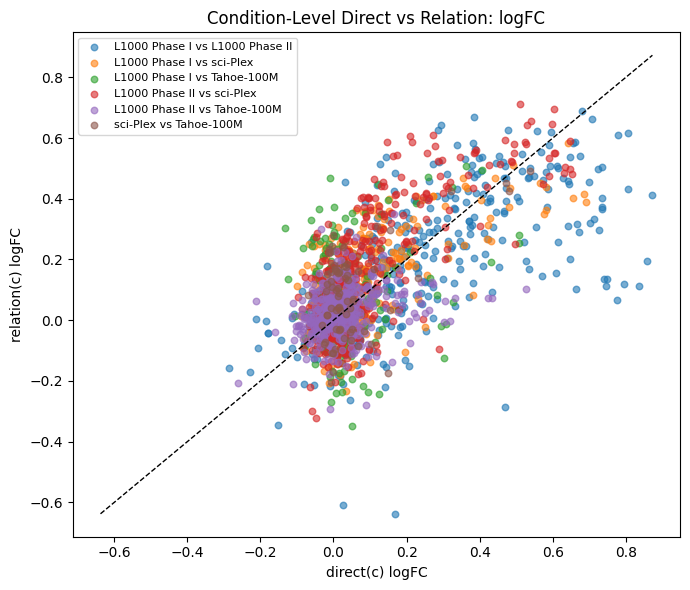

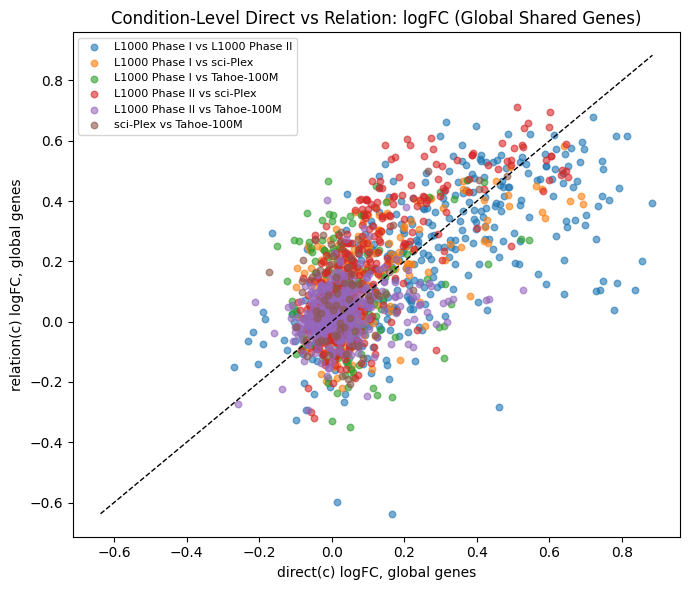

In [28]:
def plot_direct_vs_relation(plot_frame: pd.DataFrame, direct_column: str, relation_column: str, title: str, x_label: str, y_label: str) -> None:
    plot_frame = plot_frame.dropna(subset=[direct_column, relation_column]).copy()
    if plot_frame.empty:
        print(f"No finite points available for {title}.")
        return
    plot_frame["dataset_pair"] = plot_frame["dataset_a"].map(pretty_label) + " vs " + plot_frame["dataset_b"].map(pretty_label)

    fig, ax = plt.subplots(figsize=(7, 6))
    for dataset_pair, pair_frame in plot_frame.groupby("dataset_pair", sort=False):
        ax.scatter(
            pair_frame[direct_column],
            pair_frame[relation_column],
            alpha=0.6,
            s=22,
            label=dataset_pair,
        )
    lims = [
        float(np.nanmin([plot_frame[direct_column].min(), plot_frame[relation_column].min()])),
        float(np.nanmax([plot_frame[direct_column].max(), plot_frame[relation_column].max()])),
    ]
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


plot_direct_vs_relation(
    relative_structure_condition_scores,
    direct_column="direct_spearman_logfc",
    relation_column="relation_spearman_logfc",
    title="Condition-Level Direct vs Relation: logFC",
    x_label="direct(c) logFC",
    y_label="relation(c) logFC",
)
plot_direct_vs_relation(
    relative_structure_condition_scores,
    direct_column="direct_spearman_logfc_global",
    relation_column="relation_spearman_logfc_global",
    title="Condition-Level Direct vs Relation: logFC (Global Shared Genes)",
    x_label="direct(c) logFC, global genes",
    y_label="relation(c) logFC, global genes",
)


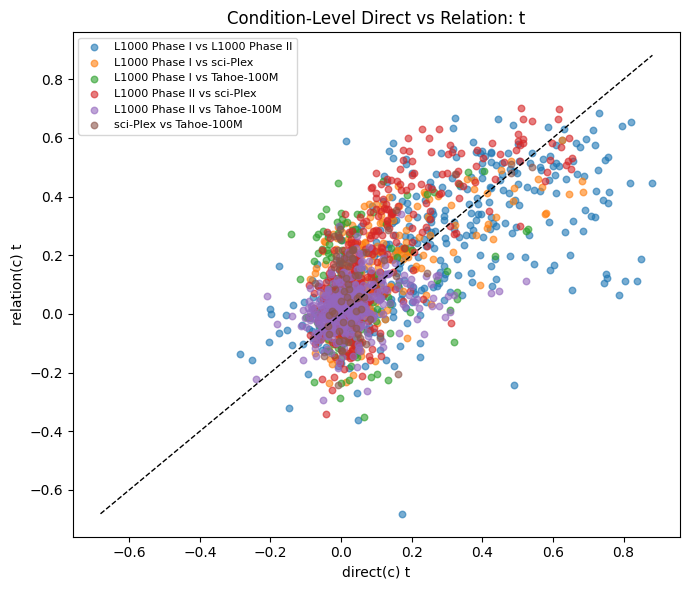

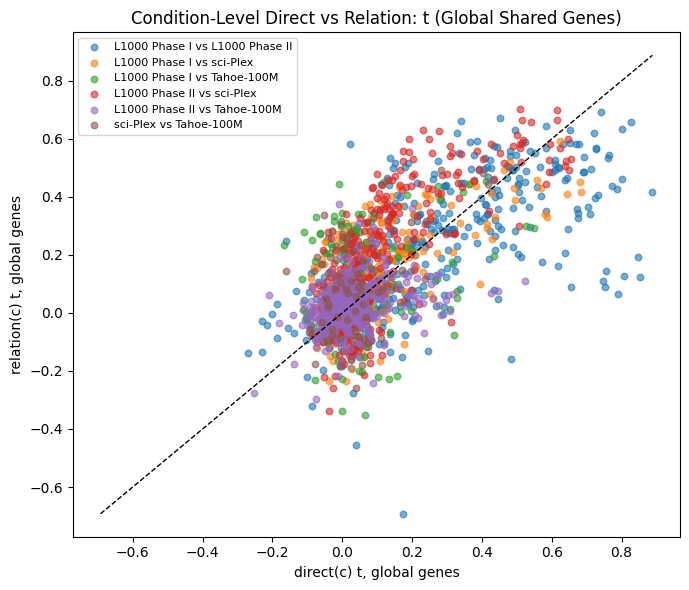

In [29]:
def plot_direct_vs_relation(plot_frame: pd.DataFrame, direct_column: str, relation_column: str, title: str, x_label: str, y_label: str) -> None:
    plot_frame = plot_frame.dropna(subset=[direct_column, relation_column]).copy()
    if plot_frame.empty:
        print(f"No finite points available for {title}.")
        return
    plot_frame["dataset_pair"] = plot_frame["dataset_a"].map(pretty_label) + " vs " + plot_frame["dataset_b"].map(pretty_label)

    fig, ax = plt.subplots(figsize=(7, 6))
    for dataset_pair, pair_frame in plot_frame.groupby("dataset_pair", sort=False):
        ax.scatter(
            pair_frame[direct_column],
            pair_frame[relation_column],
            alpha=0.6,
            s=22,
            label=dataset_pair,
        )
    lims = [
        float(np.nanmin([plot_frame[direct_column].min(), plot_frame[relation_column].min()])),
        float(np.nanmax([plot_frame[direct_column].max(), plot_frame[relation_column].max()])),
    ]
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


plot_direct_vs_relation(
    relative_structure_condition_scores,
    direct_column="direct_spearman_t",
    relation_column="relation_spearman_t",
    title="Condition-Level Direct vs Relation: t",
    x_label="direct(c) t",
    y_label="relation(c) t",
)
plot_direct_vs_relation(
    relative_structure_condition_scores,
    direct_column="direct_spearman_t_global",
    relation_column="relation_spearman_t_global",
    title="Condition-Level Direct vs Relation: t (Global Shared Genes)",
    x_label="direct(c) t, global genes",
    y_label="relation(c) t, global genes",
)


Optional cleanup:

```python
close_all_line_sources()
```
